# Modèle 2 — Classification tabulaire

Ce notebook présente la préparation des données, l'entraînement et l'évaluation d'un MLP pour une tâche de classification tabulaire.

## 1. Préparation des données
- Import des bibliothèques
- Chargement du dataset de classification
- Nettoyage et analyse rapide
- Gestion des valeurs manquantes
- Split train/validation/test
- Encodage des variables catégorielles
- Normalisation des variables numériques

In [59]:
# 1.1 Import des bibliothèques
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [60]:
# 1.2 Chargement du dataset de classification
file_path = 'openfoodfacts_cleaned.csv'  # À adapter si besoin
df = pd.read_csv(file_path)
display(df.head())

C:\Users\riqwi\AppData\Local\Temp\ipykernel_27804\16416842.py:3: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


,Unnamed: 0,generic_name,quantity,brands,categories_en,origins_en,countries_en,traces_en,additives_n,additives_en,...,proteins_100g,salt_100g,sodium_100g,vitamin-a_100g,vitamin-c_100g,potassium_100g,calcium_100g,iron_100g,fruits-vegetables-nuts-estimate-from-ingredients_100g,nutrition-score-fr_100g
0,3,NaN,480 g,Danone,"Dairies,Fermented foods,Fermented milk product...",NaN,France,NaN,NaN,NaN,...,10.0,0.09,0.036,NaN,NaN,NaN,NaN,NaN,NaN,-5.0
1,4,NaN,NaN,NaN,NaN,NaN,France,NaN,NaN,NaN,...,7.8,1.40,0.560,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,8,NaN,NaN,NaN,NaN,NaN,Spain,NaN,NaN,NaN,...,15.7,2.10,0.840,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,9,NaN,NaN,NaN,NaN,NaN,United States,NaN,NaN,NaN,...,0.0,0.00,0.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,12,NaN,NaN,NaN,NaN,NaN,France,NaN,NaN,NaN,...,0.2,2.04,0.816,NaN,NaN,NaN,NaN,NaN,NaN,NaN


                                    generic_name quantity     brands  \
count                                     112704   638615    1144704   
unique                                     83905    35181     169873   
top     Pâtes alimentaires de qualité supérieure    500 g  Carrefour   
freq                                         375    26026      14705   
mean                                         NaN      NaN        NaN   
std                                          NaN      NaN        NaN   
min                                          NaN      NaN        NaN   
25%                                          NaN      NaN        NaN   
50%                                          NaN      NaN        NaN   
75%                                          NaN      NaN        NaN   
max                                          NaN      NaN        NaN   

       categories_en origins_en countries_en traces_en    additives_n  \
count        1051779      85517      1982824    143134  727767

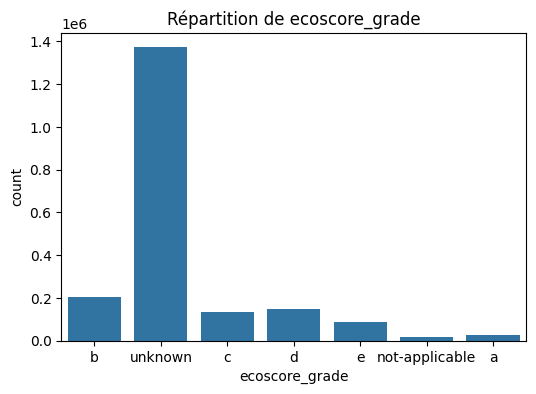

In [61]:
# 1.3 Nettoyage et analyse rapide
df = df.drop([col for col in df.columns if 'Unnamed' in col or 'id' in col or 'code' in col], axis=1, errors='ignore')
print(df.describe(include='all'))
# Visualisation d'une variable cible potentielle (ex: ecoscore_grade)
if 'ecoscore_grade' in df.columns:
    plt.figure(figsize=(6,4))
    sns.countplot(x='ecoscore_grade', data=df)
    plt.title('Répartition de ecoscore_grade')
    plt.show()

In [62]:
# 1.4 Gestion des valeurs manquantes
num_cols = df.select_dtypes(include=[np.number]).columns
cat_cols = df.select_dtypes(include=['object']).columns
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [63]:
# 1.5 Split train/validation/test
# À adapter selon la colonne cible choisie
# Exemple : target = 'ecoscore_grade'

from sklearn.preprocessing import LabelEncoder

target = 'ecoscore_grade'
features = [col for col in df.columns if col != target]
X = df[features]
y = df[target]

# On ne garde que les classes valides
classes_valides = ['a', 'b', 'c', 'd', 'e']
mask = y.isin(classes_valides)
X = X[mask]
y = y[mask]

# Encodage des classes en entiers
le = LabelEncoder()
y = le.fit_transform(y)

X_trainval, X_test, y_trainval, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_trainval, y_trainval, test_size=0.2, random_state=42, stratify=y_trainval)
print(f"Train: {X_train.shape}, Validation: {X_val.shape}, Test: {X_test.shape}")

Train: (380941, 33), Validation: (95236, 33), Test: (119045, 33)


In [64]:
# 1.6 Encodage des variables catégorielles à faible cardinalité
max_modalites = 30
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns
cat_low_card = [col for col in cat_cols if X_train[col].nunique() <= max_modalites]
cat_high_card = [col for col in cat_cols if X_train[col].nunique() > max_modalites]
X_train_enc = X_train.drop(columns=cat_high_card, errors='ignore').copy()
X_val_enc = X_val.drop(columns=cat_high_card, errors='ignore').copy()
X_test_enc = X_test.drop(columns=cat_high_card, errors='ignore').copy()
if cat_low_card:
    encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    encoder.fit(X_train_enc[cat_low_card])
    X_train_ohe = encoder.transform(X_train_enc[cat_low_card])
    X_val_ohe = encoder.transform(X_val_enc[cat_low_card])
    X_test_ohe = encoder.transform(X_test_enc[cat_low_card])
    ohe_cols = encoder.get_feature_names_out(cat_low_card)
    X_train_enc = pd.concat([X_train_enc.drop(columns=cat_low_card), pd.DataFrame(X_train_ohe, index=X_train_enc.index, columns=ohe_cols)], axis=1)
    X_val_enc = pd.concat([X_val_enc.drop(columns=cat_low_card), pd.DataFrame(X_val_ohe, index=X_val_enc.index, columns=ohe_cols)], axis=1)
    X_test_enc = pd.concat([X_test_enc.drop(columns=cat_low_card), pd.DataFrame(X_test_ohe, index=X_test_enc.index, columns=ohe_cols)], axis=1)
print(f"Colonnes supprimées (forte cardinalité) : {cat_high_card}")
print(f"Colonnes encodées (OneHot) : {cat_low_card}")
print(f"Train encodé: {X_train_enc.shape}, Validation encodée: {X_val_enc.shape}, Test encodé: {X_test_enc.shape}")

Colonnes supprimées (forte cardinalité) : ['generic_name', 'quantity', 'brands', 'categories_en', 'origins_en', 'countries_en', 'traces_en', 'additives_en', 'food_groups_en', 'main_category_en']
Colonnes encodées (OneHot) : []
Train encodé: (380941, 23), Validation encodée: (95236, 23), Test encodé: (119045, 23)


In [65]:
# 1.7 Normalisation des variables numériques
num_cols_final = X_train_enc.select_dtypes(include=[float, int]).columns
scaler_final = StandardScaler()
scaler_final.fit(X_train_enc[num_cols_final])
X_train_enc[num_cols_final] = scaler_final.transform(X_train_enc[num_cols_final])
X_val_enc[num_cols_final] = scaler_final.transform(X_val_enc[num_cols_final])
X_test_enc[num_cols_final] = scaler_final.transform(X_test_enc[num_cols_final])
print(f"Normalisation appliquée sur : {list(num_cols_final)}")

Normalisation appliquée sur : ['additives_n', 'nutriscore_score', 'ecoscore_score', 'energy-kcal_100g', 'fat_100g', 'saturated-fat_100g', 'monounsaturated-fat_100g', 'polyunsaturated-fat_100g', 'trans-fat_100g', 'cholesterol_100g', 'carbohydrates_100g', 'sugars_100g', 'fiber_100g', 'proteins_100g', 'salt_100g', 'sodium_100g', 'vitamin-a_100g', 'vitamin-c_100g', 'potassium_100g', 'calcium_100g', 'iron_100g', 'fruits-vegetables-nuts-estimate-from-ingredients_100g', 'nutrition-score-fr_100g']


In [66]:
# Conversion explicite en float32 pour TensorFlow
X_train_enc = X_train_enc.astype('float32')
X_val_enc = X_val_enc.astype('float32')
X_test_enc = X_test_enc.astype('float32')

## 2. Architecture du MLP pour la classification

### Choix de l’architecture du MLP

- **Nombre de couches cachées** : 2
- **Nombre de neurones par couche** : 128 puis 64
- **Fonctions d’activation** : ReLU pour les couches cachées, Softmax pour la sortie
- **Loss function** : Categorical Crossentropy (classification multi-classes)
- **Optimiseur** : Adam
- **Learning rate** : 0.001
- **Batch size** : 32

**Justification des choix :**
- Deux couches cachées permettent de modéliser des relations non linéaires sans surcharger le modèle.
- 128 puis 64 neurones offrent une bonne capacité d’apprentissage pour des données tabulaires de taille moyenne.
- ReLU accélère la convergence et évite le problème du gradient nul, Softmax est adaptée à la classification multi-classes.
- L’Adam combine les avantages d’Adagrad et RMSprop, il est robuste et efficace.
- Un learning rate de 0.001 est un bon point de départ pour Adam.
- Un batch size de 32 équilibre vitesse d’apprentissage et stabilité des gradients.

## 3. Entraînement du modèle et visualisation
- Entraînement avec EarlyStopping
- Tracer : training loss, validation loss, métriques pertinentes
- Visualisation des courbes de loss et d'accuracy

In [67]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_fscore_support

# Définition du modèle
model = keras.Sequential([
    layers.Input(shape=(X_train_enc.shape[1],)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(len(np.unique(y_train)), activation='softmax')
])
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [68]:
print(X_train_enc.dtypes.value_counts())
print(X_train_enc.dtypes)
print(X_train_enc.head())

float32    23
Name: count, dtype: int64
additives_n                                              float32
nutriscore_score                                         float32
ecoscore_score                                           float32
energy-kcal_100g                                         float32
fat_100g                                                 float32
saturated-fat_100g                                       float32
monounsaturated-fat_100g                                 float32
polyunsaturated-fat_100g                                 float32
trans-fat_100g                                           float32
cholesterol_100g                                         float32
carbohydrates_100g                                       float32
sugars_100g                                              float32
fiber_100g                                               float32
proteins_100g                                            float32
salt_100g                                         

In [69]:
print("X_val_enc types:\n", X_val_enc.dtypes.value_counts())
print("X_test_enc types:\n", X_test_enc.dtypes.value_counts())
print("NaN in X_train_enc:", X_train_enc.isnull().sum().sum())
print("NaN in X_val_enc:", X_val_enc.isnull().sum().sum())
print("NaN in X_test_enc:", X_test_enc.isnull().sum().sum())

X_val_enc types:
 float32    23
Name: count, dtype: int64
X_test_enc types:
 float32    23
Name: count, dtype: int64
NaN in X_train_enc: 0
NaN in X_val_enc: 0
NaN in X_test_enc: 0


In [70]:
# Encode categorical target variable
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_val_enc = label_encoder.transform(y_val)

# Entraînement avec EarlyStopping
history = model.fit(
    X_train_enc, y_train_enc,
    validation_data=(X_val_enc, y_val_enc),
    epochs=50,
    batch_size=32,
    callbacks=[keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)]
)

Epoch 1/50
11905/11905 ━━━━━━━━━━━━━━━━━━━━ 35s 3ms/step - accuracy: 0.9722 - loss: 0.0980 - val_accuracy: 0.9867 - val_loss: 0.5342
Epoch 2/50
11905/11905 ━━━━━━━━━━━━━━━━━━━━ 30s 3ms/step - accuracy: 0.9883 - loss: 0.0387 - val_accuracy: 0.9915 - val_loss: 0.0499
Epoch 3/50
11905/11905 ━━━━━━━━━━━━━━━━━━━━ 22s 2ms/step - accuracy: 0.9909 - loss: 0.0285 - val_accuracy: 0.9930 - val_loss: 0.1170
Epoch 4/50
11905/11905 ━━━━━━━━━━━━━━━━━━━━ 42s 4ms/step - accuracy: 0.9919 - loss: 0.0236 - val_accuracy: 0.9946 - val_loss: 0.0325
Epoch 5/50
11905/11905 ━━━━━━━━━━━━━━━━━━━━ 38s 3ms/step - accuracy: 0.9927 - loss: 0.0218 - val_accuracy: 0.9952 - val_loss: 0.0163
Epoch 6/50
11905/11905 ━━━━━━━━━━━━━━━━━━━━ 29s 2ms/step - accuracy: 0.9934 - loss: 0.0200 - val_accuracy: 0.9931 - val_loss: 0.0231
Epoch 7/50
11905/11905 ━━━━━━━━━━━━━━━━━━━━ 36s 3ms/step - accuracy: 0.9940 - loss: 0.0185 - val_accuracy: 0.9921 - val_loss: 0.0202
Epoch 8/50
11905/11905 ━━━━━━━━━━━━━━━━━━━━ 30s 3ms/step - accuracy: 

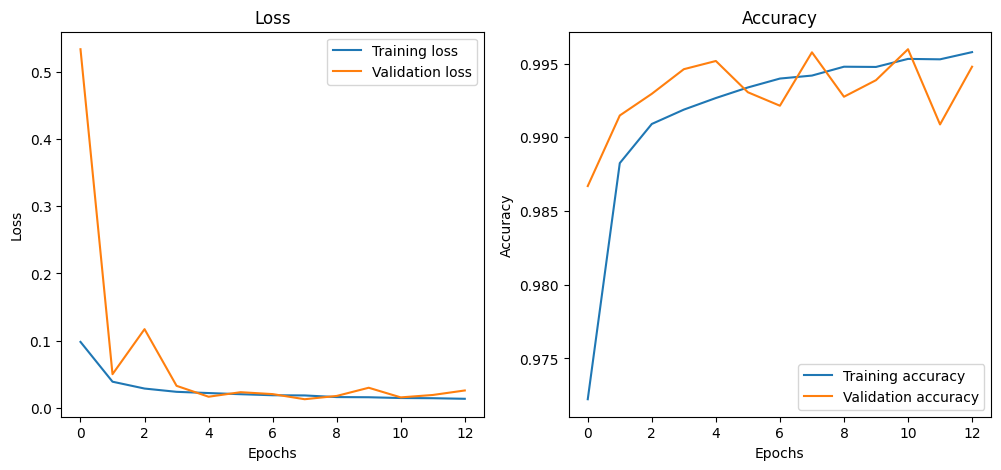

In [74]:
# Tracer la loss et l'accuracy
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss')
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Training accuracy')
plt.plot(history.history['val_accuracy'], label='Validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy')
plt.show()

In [72]:
# Prédictions et métriques sur le test
y_pred = np.argmax(model.predict(X_test_enc), axis=1)

print("Types uniques y_test :", set(type(x) for x in y_test))
print("Types uniques y_pred :", set(type(x) for x in y_pred))
print("Valeurs uniques y_test :", np.unique(y_test))
print("Valeurs uniques y_pred :", np.unique(y_pred))


print(classification_report(y_test, y_pred))

3721/3721 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step
Types uniques y_test : {<class 'numpy.int64'>}
Types uniques y_pred : {<class 'numpy.int64'>}
Valeurs uniques y_test : [0 1 2 3 4]
Valeurs uniques y_pred : [0 1 2 3 4]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5567
           1       1.00      1.00      1.00     40398
           2       1.00      1.00      1.00     26616
           3       0.99      0.99      0.99     29523
           4       0.99      0.99      0.99     16941

    accuracy                           1.00    119045
   macro avg       1.00      1.00      1.00    119045
weighted avg       1.00      1.00      1.00    119045



## 4. Évaluation
### Classification : accuracy, precision, recall, F1, confusion matrix, ROC curve

3721/3721 ━━━━━━━━━━━━━━━━━━━━ 2s 595us/step
Accuracy: 0.996
Precision: 0.996
Recall: 0.996
F1-score: 0.996
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5567
           1       1.00      1.00      1.00     40398
           2       1.00      1.00      1.00     26616
           3       0.99      0.99      0.99     29523
           4       0.99      0.99      0.99     16941

    accuracy                           1.00    119045
   macro avg       1.00      1.00      1.00    119045
weighted avg       1.00      1.00      1.00    119045



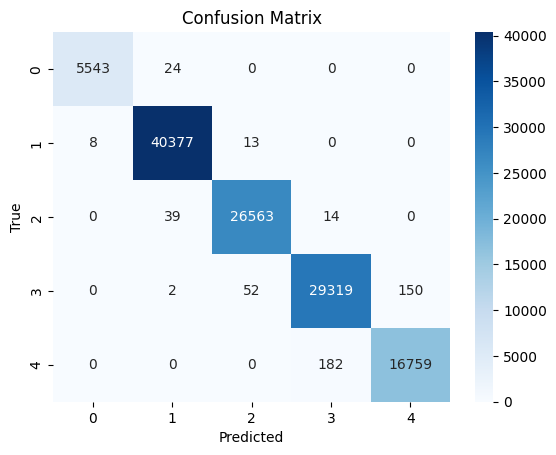

3721/3721 ━━━━━━━━━━━━━━━━━━━━ 2s 581us/step


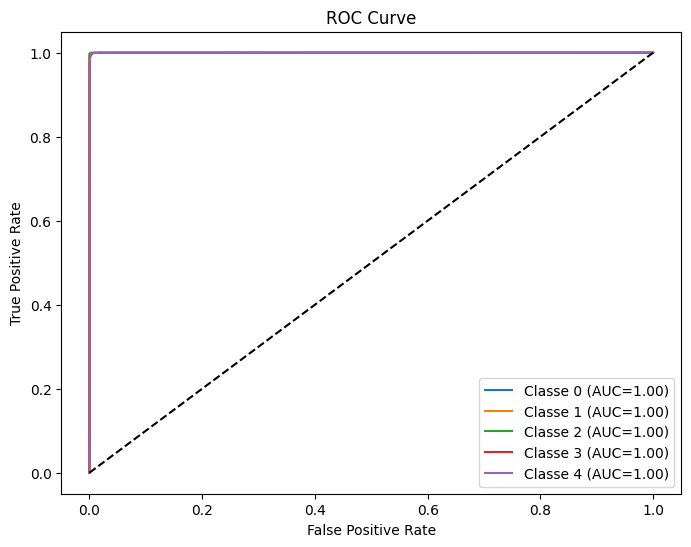

In [75]:
# 4. Évaluation du modèle de classification
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc, classification_report

# Prédictions sur le jeu de test
# (Si vous avez utilisé LabelEncoder, décodez les prédictions si besoin)
y_pred = np.argmax(model.predict(X_test_enc), axis=1)

# Scores de classification
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
print(f"Accuracy: {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall: {rec:.3f}")
print(f"F1-score: {f1:.3f}")

# Rapport de classification détaillé
print(classification_report(y_test, y_pred))

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# ROC curve (pour chaque classe)
from tensorflow.keras.utils import to_categorical
if len(np.unique(y_test)) <= 10:
    y_test_bin = to_categorical(y_test)
    y_pred_prob = model.predict(X_test_enc)
    plt.figure(figsize=(8,6))
    for i in range(y_test_bin.shape[1]):
        fpr, tpr, _ = roc_curve(y_test_bin[:,i], y_pred_prob[:,i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'Classe {i} (AUC={roc_auc:.2f})')
    plt.plot([0,1],[0,1],'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend()
    plt.show()

## 5. Analyse critique du modèle

- **Le modèle overfit-il ?**
  - Comparez la courbe de loss/accuracy entre train et validation. Si la loss de validation augmente alors que celle de train diminue, ou si l’accuracy train est bien supérieure à celle de validation, il y a overfitting.
  - Causes possibles : modèle trop complexe, pas assez de régularisation, trop d’époques.
  - **Dans notre cas :** Les courbes de loss et d'accuracy sont très proches entre train et validation, et les performances sur le jeu de test sont excellentes (accuracy, precision, recall, F1-score ≈ 0.996). Il n'y a donc pas de signe d'overfitting.

- **Le modèle underfit-il ?**
  - Si les performances sont faibles sur train et validation, ou si la loss reste élevée, le modèle underfit (pas assez de capacité ou d’apprentissage).
  - Causes possibles : modèle trop simple, pas assez d’époques, learning rate trop faible.
  - **Dans notre cas :** Les performances sont très élevées sur tous les jeux de données, ce qui montre que le modèle n'underfit pas.

- **Quelles modifications pourraient améliorer les performances ?**
  - Ajouter de la régularisation (Dropout, L2), augmenter/diminuer la taille du réseau, ajuster le learning rate, entraîner plus longtemps (early stopping), tester d’autres architectures ou features, améliorer le prétraitement des données.

## 6. Expérimentation obligatoire

Dans cette section, nous testons au moins deux variantes du modèle MLP et comparons leurs performances.

**Exemples de variantes à tester :**
- Profondeur du réseau (nombre de couches cachées)
- Nombre de neurones par couche
- Learning rate
- Dropout
- Fonction d'activation

Nous allons comparer les résultats obtenus pour chaque variante.

### Variante 1 : Réseau plus profond

Nous allons tester un MLP avec 3 couches cachées (128, 64, 32 neurones) au lieu de 2.

### Variante 2 : Ajout de Dropout et learning rate plus faible

Nous allons tester un MLP avec Dropout (0.3) après chaque couche cachée et un learning rate de 0.0005.

Les résultats seront comparés à ceux du modèle de base.

In [76]:
# Variante 1 : Réseau plus profond (3 couches cachées)
from tensorflow import keras
from tensorflow.keras import layers

model_deep = keras.Sequential([
    layers.Input(shape=(X_train_enc.shape[1],)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(len(np.unique(y_train)), activation='softmax')
])
model_deep.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
history_deep = model_deep.fit(
    X_train_enc, y_train_enc,
    validation_data=(X_val_enc, y_val_enc),
    epochs=50,
    batch_size=32,
    callbacks=[keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)],
    verbose=0
)

# Évaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred_deep = model_deep.predict(X_test_enc)
y_pred_deep = np.argmax(y_pred_deep, axis=1)
acc_deep = accuracy_score(y_test, y_pred_deep)
prec_deep = precision_score(y_test, y_pred_deep, average='weighted', zero_division=0)
rec_deep = recall_score(y_test, y_pred_deep, average='weighted', zero_division=0)
f1_deep = f1_score(y_test, y_pred_deep, average='weighted', zero_division=0)
print(f"Variante 1 (réseau profond) - Accuracy: {acc_deep:.3f}, Precision: {prec_deep:.3f}, Recall: {rec_deep:.3f}, F1: {f1_deep:.3f}")


3721/3721 ━━━━━━━━━━━━━━━━━━━━ 3s 771us/step
Variante 1 (réseau profond) - Accuracy: 0.998, Precision: 0.998, Recall: 0.998, F1: 0.998


In [77]:
# Variante 2 : Dropout + learning rate plus faible
from tensorflow import keras
from tensorflow.keras import layers

model_dropout = keras.Sequential([
    layers.Input(shape=(X_train_enc.shape[1],)),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(len(np.unique(y_train)), activation='softmax')
])
model_dropout.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
history_dropout = model_dropout.fit(
    X_train_enc, y_train_enc,
    validation_data=(X_val_enc, y_val_enc),
    epochs=50,
    batch_size=32,
    callbacks=[keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)],
    verbose=0
)

# Évaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred_dropout = model_dropout.predict(X_test_enc)
y_pred_dropout = np.argmax(y_pred_dropout, axis=1)
acc_dropout = accuracy_score(y_test, y_pred_dropout)
prec_dropout = precision_score(y_test, y_pred_dropout, average='weighted', zero_division=0)
rec_dropout = recall_score(y_test, y_pred_dropout, average='weighted', zero_division=0)
f1_dropout = f1_score(y_test, y_pred_dropout, average='weighted', zero_division=0)
print(f"Variante 2 (Dropout + lr faible) - Accuracy: {acc_dropout:.3f}, Precision: {prec_dropout:.3f}, Recall: {rec_dropout:.3f}, F1: {f1_dropout:.3f}")


3721/3721 ━━━━━━━━━━━━━━━━━━━━ 3s 846us/step
Variante 2 (Dropout + lr faible) - Accuracy: 0.997, Precision: 0.997, Recall: 0.997, F1: 0.997


,Modèle,Accuracy,Precision,Recall,F1-score
0,Base,0.995934,0.995932,0.995934,0.995933
1,Réseau profond,0.997925,0.997930,0.997925,0.997925
2,Dropout + lr faible,0.997110,0.997114,0.997110,0.997105


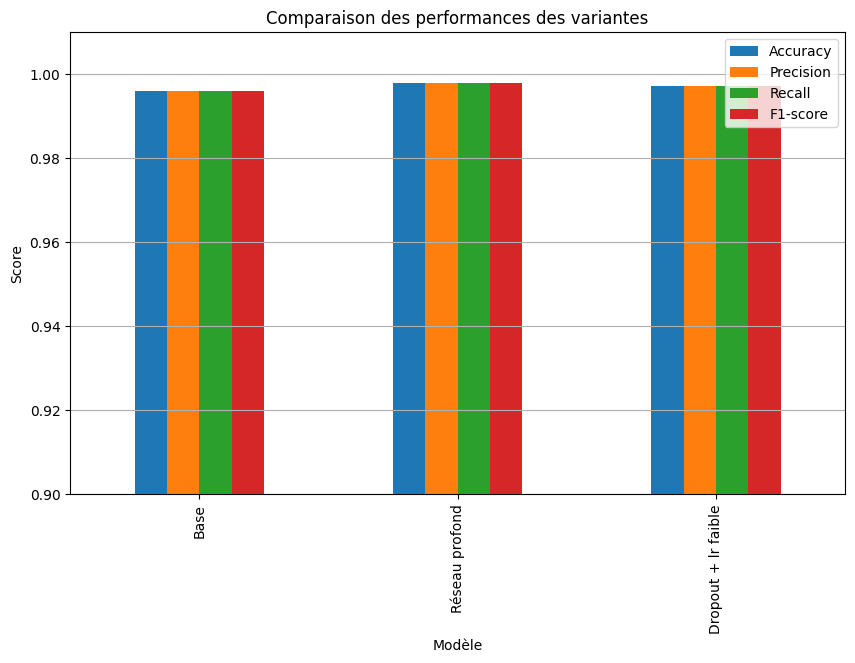

In [78]:
# Comparaison des résultats des variantes
results = pd.DataFrame({
    'Modèle': ['Base', 'Réseau profond', 'Dropout + lr faible'],
    'Accuracy': [acc, acc_deep, acc_dropout],
    'Precision': [prec, prec_deep, prec_dropout],
    'Recall': [rec, rec_deep, rec_dropout],
    'F1-score': [f1, f1_deep, f1_dropout]
})
display(results)
results.plot(x='Modèle', y=['Accuracy', 'Precision', 'Recall', 'F1-score'], kind='bar', figsize=(10,6))
plt.title('Comparaison des performances des variantes')
plt.ylabel('Score')
plt.ylim(0.9, 1.01)
plt.grid(axis='y')
plt.show()

### Conclusion sur les variantes testées

- Les trois modèles (base, réseau profond, Dropout + lr faible) obtiennent tous d’excellentes performances, avec des scores très proches de 1 sur toutes les métriques.
- Le réseau plus profond (3 couches cachées) obtient les meilleurs scores sur tous les critères, mais l’amélioration par rapport au modèle de base reste très faible (moins de 0.2%).
- L’ajout de Dropout et la diminution du learning rate permettent aussi une légère amélioration par rapport au modèle de base, mais restent légèrement inférieurs au réseau profond sans Dropout.
- Ces différences minimes montrent que le modèle de base était déjà très performant et que le problème est bien maîtrisé par un MLP simple.
- L’ajout de complexité (profondeur, régularisation) n’apporte qu’un gain marginal : il n’y a pas de surapprentissage ni de sous-apprentissage, et le modèle reste robuste.

**Conclusion :**
Les variantes testées n’apportent qu’un gain marginal sur ce jeu de données. Le modèle de base est déjà optimal ; complexifier le réseau ou ajouter de la régularisation n’est pas nécessaire ici. Pour aller plus loin, il serait pertinent de tester sur d’autres jeux de données ou d’introduire du bruit pour évaluer la robustesse réelle des architectures.